# Sistema de Diagnóstico de Doenças com Machine Learning

Este projeto tem como objetivo prever a ocorrência de doenças hepáticas com base em dados médicos, utilizando técnicas de classificação supervisionada.


## Datasets utilizados

[Indian Liver Patient Dataset (ILPD)](https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset) 

Os dados foram obtidos de fontes públicas e utilizados em tarefas de classificação supervisionada para predição de doenças.

In [31]:
# Importação das bibliotecas essenciais:
# pandas: manipulação de dados
# matplotlib e seaborn: visualização de dados
# missingno: análise de valores ausentes

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [33]:
# Carregamento do dataset de doenças hepáticas
# Visualização das primeiras linhas

In [34]:
dados = pd.read_csv('Indian Liver Patient Dataset (ILPD).csv', header=None)
dados.head()

,0,1,2,3,4,5,6,7,8,9,10
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [35]:
dados.columns = [
    'Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
    'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase', 'Total_Proteins',
    'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset'
]

## Descrição do Dataset (ILPD)

Os nomes das colunas foram definidos com base na documentação oficial do dataset Indian Liver Patient Dataset (ILPD), disponível no repositório UCI Machine Learning Repository.

O dataset não possui cabeçalho no arquivo original, sendo necessário atribuir manualmente os nomes das variáveis conforme a especificação da base de dados.

As colunas representam informações clínicas dos pacientes, incluindo idade, gênero, exames laboratoriais e a variável alvo (Dataset), que indica a presença ou ausência de doença hepática.

In [36]:
dados.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')

In [37]:
dados.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [38]:
dados.shape

(583, 11)

In [39]:
# Análise da distribuição do target

In [40]:
dados['Dataset'].value_counts()

Dataset
1    416
2    167
Name: count, dtype: int64

In [41]:
# ajuste do target para padrão binário (0 = não, 1 = sim)

In [42]:
dados['Dataset'] = dados['Dataset'].map({1: 1, 2: 0})

In [43]:
# conversão da variável Gender para numérico
dados['Gender'] = dados['Gender'].map({'Male': 0, 'Female': 1})

In [44]:
dados['Gender'].head()

0    1
1    0
2    0
3    0
4    0
Name: Gender, dtype: int64

In [45]:
dados.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,0.243568,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,0.713551
std,16.189833,0.429603,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,0.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,0.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,0.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


Foram identificados valores ausentes em algumas variáveis, sendo realizada a remoção dos registros incompletos.

In [46]:
# remoção de registros com valores ausentes
dados = dados.dropna()

In [47]:
dados.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000,579.000000
mean,44.782383,0.241796,3.315371,1.494128,291.366149,81.126079,110.414508,6.481693,3.138515,0.947064,0.715026
std,16.221786,0.428542,6.227716,2.816499,243.561863,183.182845,289.850034,1.084641,0.794435,0.319592,0.451792
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,0.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,0.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,0.000000,2.600000,1.300000,298.000000,61.000000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


## Ajustes iniciais do dataset

Na etapa de análise exploratória, foram identificadas inconsistências estruturais no dataset.
As colunas não possuíam identificação no arquivo original, foi necessária a atribuição manual dos nomes conforme a documentação oficial, também foram detectados valores ausentes em 4 amostras, exigindo tratamento para garantir a integridade dos dados.
Esses ajustes foram realizados como etapa de pré-processamento para adequação do dataset aos modelos de Machine Learning.

In [48]:
# verificação de valores ausentes
dados.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

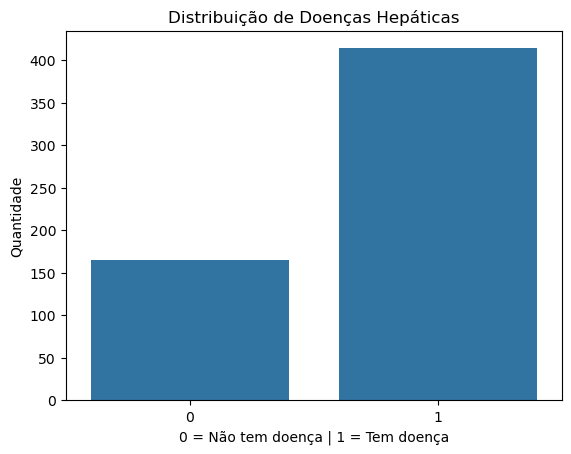

In [49]:
# distribuição das classes (presença de doença hepática)
sns.countplot(x='Dataset', data=dados)

plt.title("Distribuição de Doenças Hepáticas")
plt.xlabel("0 = Não tem doença | 1 = Tem doença")
plt.ylabel("Quantidade")

plt.show()

## Análise da distribuição das classes

Pelo gráfico, observa-se a distribuição entre pacientes que não possuem a doença hepática (0) e aqueles que possuem a doença (1). 

Nota-se que há um desbalanceamento entre as classes, com aproximadamente 150 pacientes sem a doença e cerca de 400 pacientes com a doença.

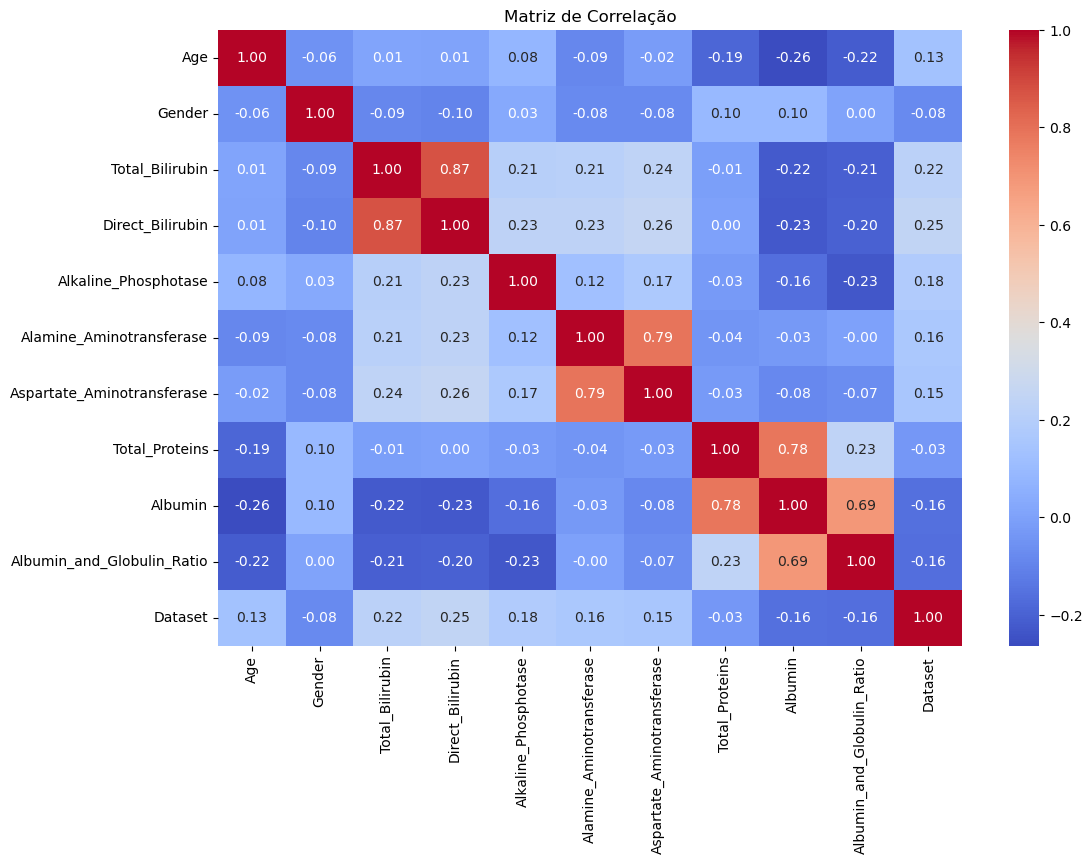

In [50]:
# matriz de correlação
dados_numeric = dados.select_dtypes(include=['number'])
plt.figure(figsize=(12,8))

#heatmap
sns.heatmap(dados_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Matriz de Correlação")
plt.show()

## Análise da correlação

A análise mostra que variáveis relacionadas à bilirrubina e enzimas hepáticas apresentam maior relação com a variável alvo, indicando que podem ser importantes para a predição da doença hepática.

Já as variáveis Albumin e Albumin_and_Globulin_Ratio apresentam relação negativa com o target (Dataset), sugerindo que valores mais altos podem estar associados a uma menor chance de doença.

Também foi possível observar que algumas variáveis possuem uma relação forte entre si, como Total_Bilirubin e Direct_Bilirubin, o que indica que podem estar trazendo informações semelhantes dentro do modelo.

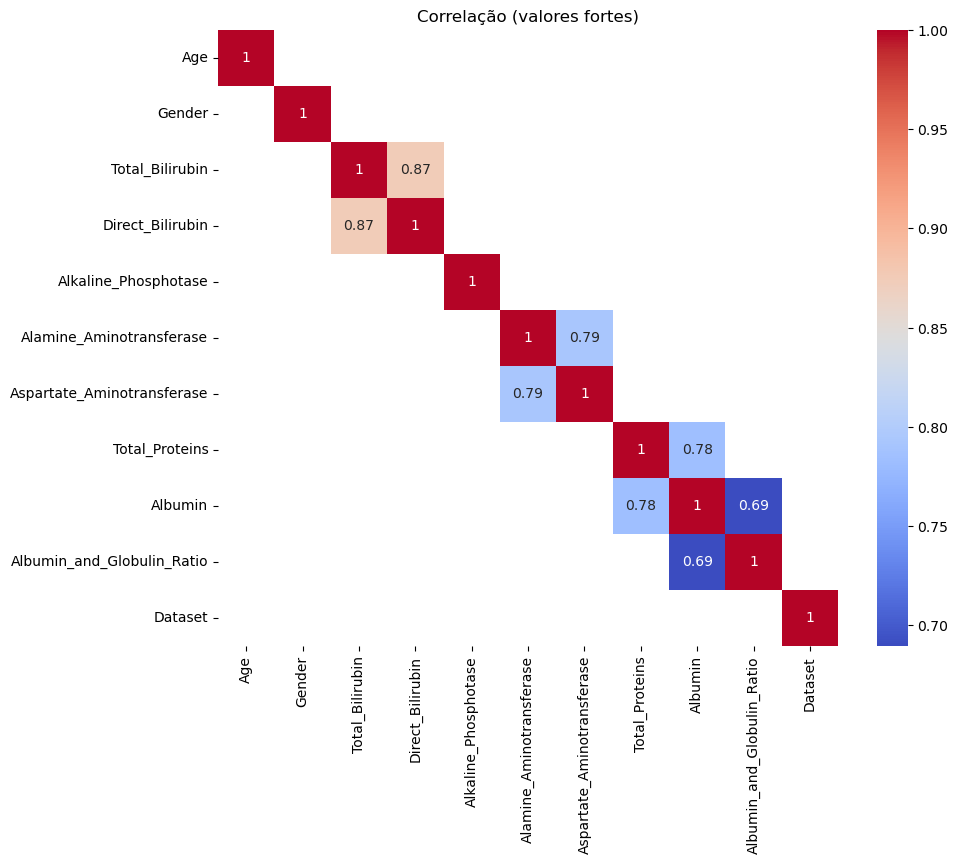

In [51]:
corr = dados.corr()

# filtra correlações fortes
strong_corr = corr[abs(corr) > 0.5]

plt.figure(figsize=(10,8))
sns.heatmap(strong_corr, annot=True, cmap='coolwarm')

plt.title("Correlação (valores fortes)")
plt.show()


## Correlação de valores fortes

Nesse outro gráfico, é possível observar o mesmo padrão, porém foi aplicado um filtro que destaca apenas as relações mais fortes (|r| > 0.5), com o objetivo de focar nas conexões mais relevantes e ignorar relações fracas que não contribuem tanto para a análise.

In [52]:
# análise da correlação das variáveis com o target
corr_target = dados.corr()['Dataset'].sort_values(ascending=False)

print(corr_target)

Dataset                       1.000000
Direct_Bilirubin              0.246273
Total_Bilirubin               0.220218
Alkaline_Phosphotase          0.183363
Alamine_Aminotransferase      0.163117
Aspartate_Aminotransferase    0.151834
Age                           0.133164
Total_Proteins               -0.033614
Gender                       -0.081349
Albumin                      -0.159770
Albumin_and_Globulin_Ratio   -0.163131
Name: Dataset, dtype: float64


## Análise da correlação com o target (tabela)

Como forma adicional de visualização, a tabela acima apresenta as correlações entre as variáveis e o target (Dataset), permitindo uma leitura mais direta dos valores e facilitando a comparação com o gráfico anterior.

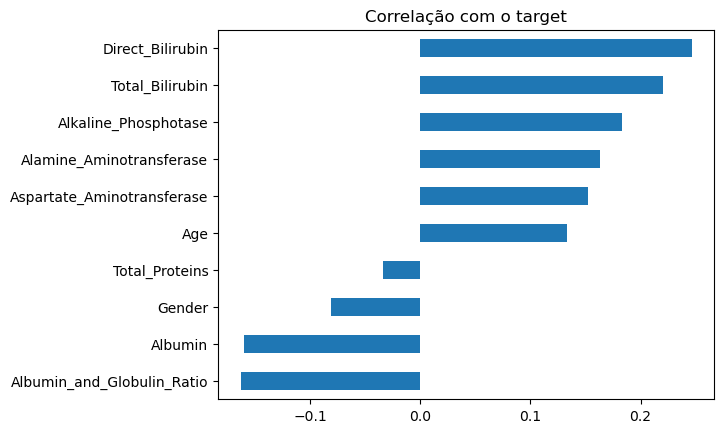

In [53]:
## análise da correlação das variáveis com o target
corr_target = dados.corr()['Dataset'].drop('Dataset')

corr_target.sort_values().plot(kind='barh')

plt.title("Correlação com o target")
plt.show()

## Correlação com o target

Outro gráfico onde é possível observar a correlação de cada variável em relação ao target (*Dataset*). As variáveis estão organizadas da menor para a maior correlação, permitindo identificar quais possuem relação negativa ou positiva com a presença da doença. Valores mais próximos de 1 indicam maior associação positiva, enquanto valores próximos de -1 indicam associação negativa, e valores próximos de 0 indicam pouca ou nenhuma relação linear.


In [56]:
# ajustar o peso das classes para lidar com desbalanceamento
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

Como os dados apresentavam desbalanceamento entre as classes, foi utilizado o parâmetro class_weight='balanced' na regressão logística para dar maior peso à classe minoritária e melhorar o aprendizado do modelo.

In [57]:
# separação dos dados em treino e teste para avaliação do modelo
X = dados.drop('Dataset', axis=1)
y = dados['Dataset']

In [58]:
# divisão em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
# treinar regressão logística
model.fit(X_train, y_train)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Durante o treinamento do modelo, foi identificado um ConvergenceWarning, indicando que a Regressão Logística não conseguiu convergir dentro do limite padrão de iterações. Isso pode ocorrer devido à falta de padronização dos dados ou à complexidade das variáveis. Para solucionar esse problema, será aplicada a normalização das features e, se necessário, o aumento do parâmetro max_iter, garantindo melhor ajuste e estabilidade do modelo.

In [60]:
# padronizar os dados
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
# treinar novamente
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [62]:
# fazer previsões
y_pred = model.predict(X_test_scaled)

In [63]:
# avaliar o modelo
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))

Accuracy: 0.6810344827586207

Matriz de Confusão:
 [[26  7]
 [30 53]]

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.46      0.79      0.58        33
           1       0.88      0.64      0.74        83

    accuracy                           0.68       116
   macro avg       0.67      0.71      0.66       116
weighted avg       0.76      0.68      0.70       116



Inicialmente, foi utilizada uma avaliação mais completa com múltiplas métricas. No entanto, para tornar a análise mais objetiva e alinhada ao problema, foram selecionadas as métricas de acurácia, recall e F1-score, que melhor representam o desempenho do modelo neste contexto.

In [72]:
from sklearn.metrics import recall_score, f1_score

In [73]:

recall_score(y_test, y_pred)
f1_score(y_test, y_pred)

0.7412587412587412

Foram calculadas as métricas de avaliação do modelo, obtendo-se um recall de 0.74 e um F1-score de 0.74. O recall indica que o modelo conseguiu identificar corretamente cerca de 74% dos casos em que a doença realmente estava presente, enquanto deixou de identificar aproximadamente 26% desses casos, classificando-os como saudáveis. Já o F1-score representa um equilíbrio entre os acertos e erros do modelo nesse contexto. Dessa forma, a análise conjunta das métricas de recall e F1-score permite uma avaliação mais completa do desempenho do modelo.

Por se tratar de um problema na área da saúde, esse nível de desempenho ainda não é ideal, pois a quantidade de falsos negativos pode representar um risco significativo. Sendo assim, é necessário realizar novos ajustes e melhorias no modelo para aumentar sua capacidade de identificar corretamente os casos positivos.

In [74]:
# mostra o desempenho do modelo por classe
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.79      0.58        33
           1       0.88      0.64      0.74        83

    accuracy                           0.68       116
   macro avg       0.67      0.71      0.66       116
weighted avg       0.76      0.68      0.70       116

